# Cricket Shot Classification - 3D CNN Training

This notebook trains a 3D Convolutional Neural Network to classify
cricket batting videos into 10 different shot categories.

Each video is represented using 16 uniformly sampled frames resized
to 112 × 112 pixels.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Video preprocessing configuration

NUM_FRAMES = 16
FRAME_HEIGHT = 112
FRAME_WIDTH = 112
CHANNELS = 3

NUM_CLASSES = 10

CLASS_NAMES = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep"
]

INPUT_SHAPE = (
    NUM_FRAMES,
    FRAME_HEIGHT,
    FRAME_WIDTH,
    CHANNELS
)

print("Model input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Model input shape: (16, 112, 112, 3)
Number of classes: 10
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']


In [4]:
model = keras.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    layers.Conv3D(
        filters=32,
        kernel_size=(3, 3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling3D(
        pool_size=(1, 2, 2)
    ),

    layers.Conv3D(
        filters=64,
        kernel_size=(3, 3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling3D(
        pool_size=(2, 2, 2)
    ),

    layers.Conv3D(
        filters=128,
        kernel_size=(3, 3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling3D(
        pool_size=(2, 2, 2)
    ),

    layers.GlobalAveragePooling3D(),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 16, 112, 112,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 16, 56, 56, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 16, 56, 56, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 8, 28, 28, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 8, 28, 28, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 4, 14, 14, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,098 (1.13 MB)

 Trainable params: 297,098 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using the Adam optimizer and sparse categorical
cross-entropy loss for multi-class cricket shot classification.
Accuracy is used as the primary training metric.

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from preprocessing.dataset_loader import CricketShotDataset

TRAIN_PATH = PROJECT_ROOT / "dataset" / "cricketshot" / "train"
VAL_PATH = PROJECT_ROOT / "dataset" / "cricketshot" / "val"

train_loader = CricketShotDataset(
    dataset_dir=TRAIN_PATH,
    batch_size=2,
    shuffle=True
)

val_loader = CricketShotDataset(
    dataset_dir=VAL_PATH,
    batch_size=2,
    shuffle=False
)

print("Training videos:", train_loader.num_samples)
print("Validation videos:", val_loader.num_samples)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training videos: 1250
Validation videos: 250
Training batches: 625
Validation batches: 125


In [15]:
benchmark_history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=1,
    steps_per_epoch=20,
    validation_steps=5
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 525ms/step - accuracy: 0.1250 - loss: 2.3566 - val_accuracy: 0.0000e+00 - val_loss: 2.3138


## Full 3D CNN Training

After verifying that the 3D CNN can train successfully on the local CPU,
the model is trained using the complete training dataset and evaluated
against the validation dataset.

The first training run uses 5 epochs to evaluate learning behavior,
training time, and possible overfitting.

In [16]:
EPOCHS = 5

history_3dcnn = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 719s 1s/step - accuracy: 0.0736 - loss: 2.3081 - val_accuracy: 0.1480 - val_loss: 2.2967
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 623s 997ms/step - accuracy: 0.1552 - loss: 2.2197 - val_accuracy: 0.1840 - val_loss: 2.0976
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 671s 980ms/step - accuracy: 0.1944 - loss: 2.0922 - val_accuracy: 0.2560 - val_loss: 1.9387
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 332s 531ms/step - accuracy: 0.2008 - loss: 2.0458 - val_accuracy: 0.2680 - val_loss: 1.9028
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 453s 725ms/step - accuracy: 0.2288 - loss: 1.9847 - val_accuracy: 0.2640 - val_loss: 1.8600


In [17]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model.save(
    MODEL_DIR / "cricket_shot_3dcnn_epoch5.keras"
)

print("5-epoch model saved successfully.")

5-epoch model saved successfully.


In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_3dcnn_more = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 395s 632ms/step - accuracy: 0.2528 - loss: 1.9569 - val_accuracy: 0.2680 - val_loss: 1.9094
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 478s 765ms/step - accuracy: 0.2688 - loss: 1.9191 - val_accuracy: 0.3120 - val_loss: 1.7943
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 514s 784ms/step - accuracy: 0.2936 - loss: 1.8665 - val_accuracy: 0.2520 - val_loss: 1.8386
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 430s 668ms/step - accuracy: 0.3008 - loss: 1.8509 - val_accuracy: 0.3800 - val_loss: 1.7006
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 515s 824ms/step - accuracy: 0.3200 - loss: 1.7847 - val_accuracy: 0.3960 - val_loss: 1.6692


In [19]:
model.save("../models/cricket_shot_3dcnn_epoch10.keras")
print("10-epoch 3D CNN model saved.")

10-epoch 3D CNN model saved.


In [20]:
history_3dcnn_final = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 385s 615ms/step - accuracy: 0.3544 - loss: 1.7382 - val_accuracy: 0.3560 - val_loss: 1.6578
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 414s 662ms/step - accuracy: 0.3408 - loss: 1.7351 - val_accuracy: 0.4360 - val_loss: 1.5859
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 373s 597ms/step - accuracy: 0.3752 - loss: 1.6727 - val_accuracy: 0.4320 - val_loss: 1.5888
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 457s 730ms/step - accuracy: 0.3928 - loss: 1.6471 - val_accuracy: 0.4080 - val_loss: 1.5594
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 510s 743ms/step - accuracy: 0.3968 - loss: 1.6354 - val_accuracy: 0.4040 - val_loss: 1.5973


In [21]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model.save(
    MODEL_DIR / "cricket_shot_3dcnn_epoch15.keras"
)

print("15-epoch 3D CNN model saved successfully.")

15-epoch 3D CNN model saved successfully.


## Model Evaluation

The trained 3D CNN is evaluated using the unseen test dataset.

Evaluation includes:

- Test accuracy
- Test loss
- Confusion matrix
- Precision
- Recall
- F1-score

These metrics help determine how well the model generalizes to cricket shot videos that were not used during training.

In [8]:
TEST_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "cricketshot"
    / "test"
)

test_loader = CricketShotDataset(
    dataset_dir=TEST_PATH,
    batch_size=2,
    shuffle=False
)

print("Test videos:", test_loader.num_samples)
print("Test batches:", len(test_loader))

Test videos: 250
Test batches: 125


In [23]:
test_loss, test_accuracy = model.evaluate(
    test_loader,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 353ms/step - accuracy: 0.4440 - loss: 1.5559

Test Loss: 1.5559
Test Accuracy: 0.4440
Test Accuracy (%): 44.40%


### Classification Report and Confusion Matrix

A classification report is used to evaluate the model's performance for each cricket shot category using precision, recall and F1-score.

A confusion matrix is also generated to visualize which cricket shots are classified correctly and which classes are commonly confused with each other.

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

print("Generating predictions...")

for i in range(len(test_loader)):
    X_batch, y_batch = test_loader[i]

    predictions = model.predict(
        X_batch,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(y_batch)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed.")
print("Total test samples:", len(y_true))

Generating predictions...
Predictions completed.
Total test samples: 250


In [27]:
class_names = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       cover     0.5294    0.3600    0.4286        25
     defense     0.4706    0.9600    0.6316        25
       flick     0.3333    0.0400    0.0714        25
        hook     0.5833    0.5600    0.5714        25
    late_cut     0.3333    0.2800    0.3043        25
      lofted     0.8636    0.7600    0.8085        25
        pull     0.4375    0.2800    0.3415        25
  square_cut     0.2444    0.4400    0.3143        25
    straight     0.6111    0.4400    0.5116        25
       sweep     0.2424    0.3200    0.2759        25

    accuracy                         0.4440       250
   macro avg     0.4649    0.4440    0.4259       250
weighted avg     0.4649    0.4440    0.4259       250



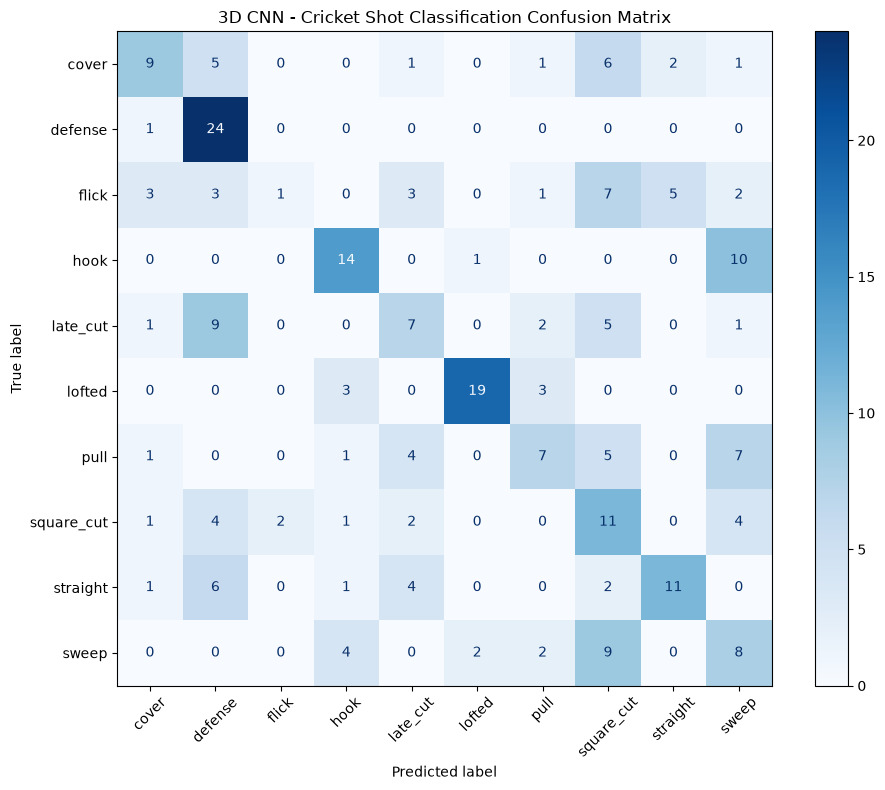

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

ax.set_title("3D CNN - Cricket Shot Classification Confusion Matrix")

plt.tight_layout()
plt.show()

## Lightweight CNN + GRU Model

The initial 3D CNN provides a baseline architecture for video classification.
However, 3D convolutions are computationally expensive for local CPU training.

Therefore, a lightweight CNN + GRU architecture is used for practical training.

The 2D CNN extracts spatial features from each individual video frame, while
the GRU learns the temporal relationship between features across the sequence
of 16 frames.

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    TimeDistributed,
    GRU,
    Dense,
    Dropout,
)


# Feature extractor for ONE video frame
frame_feature_extractor = Sequential(
    [
        Input(shape=(FRAME_HEIGHT, FRAME_WIDTH, CHANNELS)),

        Conv2D(
            16,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        MaxPooling2D((2, 2)),

        Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        MaxPooling2D((2, 2)),

        Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),

        GlobalAveragePooling2D(),
    ],
    name="frame_feature_extractor"
)


# Complete video classification model
cnn_gru_model = Sequential(
    [
        Input(
            shape=(
                NUM_FRAMES,
                FRAME_HEIGHT,
                FRAME_WIDTH,
                CHANNELS
            )
        ),

        TimeDistributed(
            frame_feature_extractor
        ),

        GRU(64),

        Dropout(0.3),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            NUM_CLASSES,
            activation="softmax"
        ),
    ],
    name="cricket_shot_cnn_gru"
)


cnn_gru_model.summary()

Model: "cricket_shot_cnn_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 64)         │        23,584 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,354 (208.41 KB)

 Trainable params: 53,354 (208.41 KB)

 Non-trainable params: 0 (0.00 B)

## CNN + GRU Compilation and Training

The CNN + GRU model separates spatial and temporal feature learning.

The CNN extracts visual features from each frame, while the GRU learns how
those features change across the sequence of 16 frames.

The model is trained using the same training and validation splits as the
3D CNN to allow a fair comparison between the two architectures.

In [29]:
cnn_gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN + GRU model compiled successfully.")

CNN + GRU model compiled successfully.


In [30]:
cnn_gru_benchmark = cnn_gru_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=1,
    steps_per_epoch=20,
    validation_steps=5
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 398ms/step - accuracy: 0.0750 - loss: 2.3178 - val_accuracy: 0.0000e+00 - val_loss: 2.3086


## Full CNN + GRU Training

After confirming that the CNN + GRU architecture trains successfully and
is computationally lighter than the 3D CNN, the model is trained on the
complete training dataset.

Early stopping is used to prevent unnecessary training when validation
performance stops improving.

In [31]:
cnn_gru_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_cnn_gru = cnn_gru_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=15,
    callbacks=[cnn_gru_early_stopping]
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 273s 437ms/step - accuracy: 0.0984 - loss: 2.3057 - val_accuracy: 0.1000 - val_loss: 2.2958
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 319s 510ms/step - accuracy: 0.1352 - loss: 2.2377 - val_accuracy: 0.1840 - val_loss: 2.0757
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 549ms/step - accuracy: 0.1904 - loss: 2.0903 - val_accuracy: 0.2200 - val_loss: 1.9503
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 242s 387ms/step - accuracy: 0.2304 - loss: 1.9923 - val_accuracy: 0.2880 - val_loss: 1.8330
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 365ms/step - accuracy: 0.2520 - loss: 1.9201 - val_accuracy: 0.3520 - val_loss: 1.7624
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 329ms/step - accuracy: 0.2768 - loss: 1.8617 - val_accuracy: 0.3160 - val_loss: 1.7475
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.2968 - loss: 1.8406 - val_accuracy: 0.3240 - val_loss: 1.8040
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 303ms/step - accuracy: 0.3376 -

In [32]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

cnn_gru_model.save(
    MODEL_DIR / "cricket_shot_cnn_gru.keras"
)

print("CNN + GRU model saved successfully.")

CNN + GRU model saved successfully.


In [33]:
cnn_gru_test_loss, cnn_gru_test_accuracy = cnn_gru_model.evaluate(
    test_loader,
    verbose=1
)

print(f"\nCNN + GRU Test Loss: {cnn_gru_test_loss:.4f}")
print(f"CNN + GRU Test Accuracy: {cnn_gru_test_accuracy:.4f}")
print(
    f"CNN + GRU Test Accuracy (%): "
    f"{cnn_gru_test_accuracy * 100:.2f}%"
)

125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 383ms/step - accuracy: 0.3720 - loss: 1.5760

CNN + GRU Test Loss: 1.5760
CNN + GRU Test Accuracy: 0.3720
CNN + GRU Test Accuracy (%): 37.20%


## Transfer Learning with MobileNetV2 + GRU

The previous 3D CNN and CNN + GRU models learned visual features mainly from
the cricket-shot dataset itself.

To improve feature quality, MobileNetV2 pretrained on ImageNet is used as a
frame-level feature extractor.

The pretrained backbone extracts spatial features from each frame, while a GRU
learns temporal relationships across the 16-frame video sequence.

The MobileNetV2 backbone is initially frozen so that only the temporal and
classification layers are trained.

In [1]:
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    GRU,
    Dense,
    Dropout,
)
from tensorflow.keras.applications import MobileNetV2


NUM_FRAMES = 16
FRAME_HEIGHT = 112
FRAME_WIDTH = 112
CHANNELS = 3
NUM_CLASSES = 10


# ---------------------------------------------------------
# Pretrained frame feature extractor
# ---------------------------------------------------------

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(
        FRAME_HEIGHT,
        FRAME_WIDTH,
        CHANNELS,
    ),
)


# Freeze pretrained MobileNetV2 layers
mobilenet_base.trainable = False


# ---------------------------------------------------------
# Complete MobileNetV2 + GRU model
# ---------------------------------------------------------

video_input = Input(
    shape=(
        NUM_FRAMES,
        FRAME_HEIGHT,
        FRAME_WIDTH,
        CHANNELS,
    ),
    name="video_input",
)


frame_features = TimeDistributed(
    mobilenet_base,
    name="mobilenet_frame_features",
)(video_input)


temporal_features = GRU(
    128,
    name="temporal_gru",
)(frame_features)


x = Dropout(
    0.4
)(temporal_features)


x = Dense(
    128,
    activation="relu"
)(x)


x = Dropout(
    0.4
)(x)


output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="shot_prediction",
)(x)


transfer_model = Model(
    inputs=video_input,
    outputs=output,
    name="mobilenetv2_gru_cricket_classifier",
)


transfer_model.summary()

C:\Users\karam\AppData\Local\Temp\ipykernel_2080\743425558.py:25: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 25s 3us/step


Model: "mobilenetv2_gru_cricket_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 16, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_frame_features        │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_gru (GRU)              │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shot_prediction (Dense)         │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817,226 (10.75 MB)

 Trainable params: 559,242 (2.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [2]:
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    GRU,
    Dense,
    Dropout,
    Lambda,
)

from tensorflow.keras.applications import MobileNetV2


NUM_FRAMES = 16
FRAME_HEIGHT = 112
FRAME_WIDTH = 112
CHANNELS = 3
NUM_CLASSES = 10


# ---------------------------------------------------------
# Pretrained MobileNetV2 backbone
# ---------------------------------------------------------

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(
        FRAME_HEIGHT,
        FRAME_WIDTH,
        CHANNELS,
    ),
)

# Freeze the pretrained backbone
mobilenet_base.trainable = False


# ---------------------------------------------------------
# Video input
# ---------------------------------------------------------

video_input = Input(
    shape=(
        NUM_FRAMES,
        FRAME_HEIGHT,
        FRAME_WIDTH,
        CHANNELS,
    ),
    name="video_input",
)


# ---------------------------------------------------------
# MobileNetV2 preprocessing
#
# Our dataset loader gives pixel values from 0 to 1.
# MobileNetV2 expects approximately -1 to 1.
# ---------------------------------------------------------

preprocessed_input = Lambda(
    lambda x: (x * 2.0) - 1.0,
    name="mobilenet_preprocessing",
)(video_input)


# ---------------------------------------------------------
# Spatial feature extraction
#
# The same pretrained MobileNetV2 processes
# each of the 16 video frames.
# ---------------------------------------------------------

frame_features = TimeDistributed(
    mobilenet_base,
    name="mobilenet_frame_features",
)(preprocessed_input)


# ---------------------------------------------------------
# Temporal feature extraction
# ---------------------------------------------------------

temporal_features = GRU(
    128,
    name="temporal_gru",
)(frame_features)


x = Dropout(
    0.4,
    name="temporal_dropout",
)(temporal_features)


x = Dense(
    128,
    activation="relu",
    name="classification_dense",
)(x)


x = Dropout(
    0.4,
    name="classification_dropout",
)(x)


# ---------------------------------------------------------
# Final 10-class prediction
# ---------------------------------------------------------

output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="shot_prediction",
)(x)


transfer_model = Model(
    inputs=video_input,
    outputs=output,
    name="mobilenetv2_gru_cricket_classifier",
)


transfer_model.summary()

C:\Users\karam\AppData\Local\Temp\ipykernel_2080\180284065.py:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(


Model: "mobilenetv2_gru_cricket_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 16, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 16, 112, 112,   │             0 │
│ (Lambda)                        │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_frame_features        │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_gru (GRU)              │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_dropout (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dense (Dense)    │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shot_prediction (Dense)         │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817,226 (10.75 MB)

 Trainable params: 559,242 (2.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(
    "MobileNetV2 + GRU model compiled successfully."
)

MobileNetV2 + GRU model compiled successfully.


In [9]:
transfer_benchmark = transfer_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=1,
    steps_per_epoch=20,
    validation_steps=5,
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.1250 - loss: 2.6615 - val_accuracy: 0.0000e+00 - val_loss: 2.2491


## R3D-18 Transfer Learning Experiment

R3D-18 is a pretrained 3D ResNet architecture designed for video recognition.

Unlike the lightweight 3D CNN trained from scratch, R3D-18 starts with pretrained
spatio-temporal features learned from a large-scale video dataset.

The final classification layer is replaced to predict the 10 cricket shot classes.
A short CPU benchmark is performed before deciding whether full fine-tuning is practical.

In [10]:
import torch
import torch.nn as nn

from torchvision.models.video import (
    r3d_18,
    R3D_18_Weights,
)


NUM_CLASSES = 10


# ---------------------------------------------------------
# Load pretrained R3D-18
# ---------------------------------------------------------

weights = R3D_18_Weights.DEFAULT

r3d_model = r3d_18(
    weights=weights
)


# ---------------------------------------------------------
# Freeze the pretrained backbone
# ---------------------------------------------------------

for parameter in r3d_model.parameters():
    parameter.requires_grad = False


# ---------------------------------------------------------
# Replace final classification layer
# ---------------------------------------------------------

in_features = r3d_model.fc.in_features

r3d_model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)


# Only the new classifier is trainable
for parameter in r3d_model.fc.parameters():
    parameter.requires_grad = True


device = torch.device("cpu")

r3d_model = r3d_model.to(device)


# ---------------------------------------------------------
# Parameter information
# ---------------------------------------------------------

total_params = sum(
    p.numel()
    for p in r3d_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in r3d_model.parameters()
    if p.requires_grad
)


print(
    "Device:",
    device
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Frozen parameters:",
    f"{total_params - trainable_params:,}"
)

print(
    "\nFinal classification layer:"
)

print(
    r3d_model.fc
)

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to C:\Users\karam/.cache\torch\hub\checkpoints\r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:13<00:00, 9.74MB/s] 

Device: cpu
Total parameters: 33,171,402
Trainable parameters: 5,130
Frozen parameters: 33,166,272

Final classification layer:
Linear(in_features=512, out_features=10, bias=True)


In [11]:
import time
import numpy as np
import torch


# Get one batch from the existing Keras loader
X_batch, y_batch = train_loader[0]

print("Original batch shape:", X_batch.shape)


# Keras format:
# (batch, frames, height, width, channels)
#
# R3D-18 expects:
# (batch, channels, frames, height, width)

X_torch = torch.tensor(
    X_batch,
    dtype=torch.float32
).permute(
    0, 4, 1, 2, 3
)


y_torch = torch.tensor(
    y_batch,
    dtype=torch.long
)


print(
    "R3D input shape:",
    X_torch.shape
)

print(
    "Labels shape:",
    y_torch.shape
)


r3d_model.eval()

start_time = time.time()

with torch.no_grad():

    outputs = r3d_model(
        X_torch
    )

elapsed_time = time.time() - start_time


print(
    "Output shape:",
    outputs.shape
)

print(
    "Forward-pass time:",
    f"{elapsed_time:.2f} seconds"
)

Original batch shape: (2, 16, 112, 112, 3)
R3D input shape: torch.Size([2, 3, 16, 112, 112])
Labels shape: torch.Size([2])
Output shape: torch.Size([2, 10])
Forward-pass time: 0.51 seconds


In [12]:
import time

import torch
import torch.nn as nn
import torch.optim as optim


# ---------------------------------------------------------
# R3D-18 normalization
#
# Our loader gives:
# (batch, frames, height, width, channels)
# with values from 0 to 1.
#
# R3D-18 expects:
# (batch, channels, frames, height, width)
# followed by Kinetics normalization.
# ---------------------------------------------------------

R3D_MEAN = torch.tensor(
    [0.43216, 0.394666, 0.37645],
    dtype=torch.float32
).view(1, 3, 1, 1, 1)


R3D_STD = torch.tensor(
    [0.22803, 0.22145, 0.216989],
    dtype=torch.float32
).view(1, 3, 1, 1, 1)


def keras_batch_to_r3d(X_batch, y_batch):
    """
    Convert a batch from our existing Keras loader
    into the format required by PyTorch R3D-18.
    """

    X = torch.tensor(
        X_batch,
        dtype=torch.float32
    )

    # Change:
    # (B, T, H, W, C)
    # to
    # (B, C, T, H, W)
    X = X.permute(
        0, 4, 1, 2, 3
    )

    # Normalize using R3D-18 / Kinetics statistics
    X = (
        X - R3D_MEAN
    ) / R3D_STD

    y = torch.tensor(
        y_batch,
        dtype=torch.long
    )

    return X, y


# ---------------------------------------------------------
# Loss and optimizer
# ---------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    r3d_model.fc.parameters(),
    lr=0.001
)


print(
    "R3D-18 training setup ready."
)

R3D-18 training setup ready.


In [13]:
r3d_model.train()

benchmark_steps = 20

running_loss = 0.0
correct = 0
total = 0

start_time = time.time()


for batch_index in range(
    benchmark_steps
):

    X_batch, y_batch = train_loader[
        batch_index
    ]

    X, y = keras_batch_to_r3d(
        X_batch,
        y_batch
    )

    optimizer.zero_grad()

    outputs = r3d_model(
        X
    )

    loss = criterion(
        outputs,
        y
    )

    loss.backward()

    optimizer.step()

    running_loss += (
        loss.item()
    )

    predicted = outputs.argmax(
        dim=1
    )

    total += y.size(0)

    correct += (
        predicted == y
    ).sum().item()


elapsed_time = (
    time.time() - start_time
)


benchmark_accuracy = (
    correct / total
)

benchmark_loss = (
    running_loss
    / benchmark_steps
)


print(
    "R3D-18 benchmark completed."
)

print(
    "Batches:",
    benchmark_steps
)

print(
    "Samples:",
    total
)

print(
    "Loss:",
    f"{benchmark_loss:.4f}"
)

print(
    "Accuracy:",
    f"{benchmark_accuracy * 100:.2f}%"
)

print(
    "Total time:",
    f"{elapsed_time:.2f} seconds"
)

print(
    "Average time per batch:",
    f"{elapsed_time / benchmark_steps:.2f} seconds"
)

R3D-18 benchmark completed.
Batches: 20
Samples: 40
Loss: 2.7225
Accuracy: 10.00%
Total time: 17.83 seconds
Average time per batch: 0.89 seconds


### R3D-18 Frozen-Backbone Training

The pretrained R3D-18 backbone is kept frozen during the initial training stage.

Only the final 10-class classification layer is trained on the cricket-shot
dataset. This preserves the pretrained spatio-temporal features while allowing
the classifier to adapt them to the cricket shot categories.

In [14]:
import time
import torch


R3D_EPOCHS = 5


r3d_train_history = {
    "loss": [],
    "accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}


for epoch in range(R3D_EPOCHS):

    # =====================================================
    # TRAINING
    # =====================================================

    r3d_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    epoch_start = time.time()


    for batch_index in range(
        len(train_loader)
    ):

        X_batch, y_batch = train_loader[
            batch_index
        ]

        X, y = keras_batch_to_r3d(
            X_batch,
            y_batch
        )

        optimizer.zero_grad()

        outputs = r3d_model(
            X
        )

        loss = criterion(
            outputs,
            y
        )

        loss.backward()

        optimizer.step()


        train_loss += loss.item()

        predicted = outputs.argmax(
            dim=1
        )

        train_total += y.size(0)

        train_correct += (
            predicted == y
        ).sum().item()


    train_loss /= len(
        train_loader
    )

    train_accuracy = (
        train_correct
        / train_total
    )


    # =====================================================
    # VALIDATION
    # =====================================================

    r3d_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for batch_index in range(
            len(val_loader)
        ):

            X_batch, y_batch = (
                val_loader[
                    batch_index
                ]
            )

            X, y = (
                keras_batch_to_r3d(
                    X_batch,
                    y_batch
                )
            )

            outputs = r3d_model(
                X
            )

            loss = criterion(
                outputs,
                y
            )

            val_loss += loss.item()

            predicted = outputs.argmax(
                dim=1
            )

            val_total += y.size(0)

            val_correct += (
                predicted == y
            ).sum().item()


    val_loss /= len(
        val_loader
    )

    val_accuracy = (
        val_correct
        / val_total
    )


    epoch_time = (
        time.time()
        - epoch_start
    )


    r3d_train_history[
        "loss"
    ].append(train_loss)

    r3d_train_history[
        "accuracy"
    ].append(train_accuracy)

    r3d_train_history[
        "val_loss"
    ].append(val_loss)

    r3d_train_history[
        "val_accuracy"
    ].append(val_accuracy)


    print(
        f"\nEpoch {epoch + 1}/{R3D_EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Epoch Time: "
        f"{epoch_time / 60:.2f} minutes"
    )


Epoch 1/5
Train Loss: 2.3423
Train Accuracy: 15.68%
Validation Loss: 1.9189
Validation Accuracy: 35.60%
Epoch Time: 12.79 minutes

Epoch 2/5
Train Loss: 2.0504
Train Accuracy: 28.16%
Validation Loss: 1.7630
Validation Accuracy: 40.00%
Epoch Time: 16.21 minutes

Epoch 3/5
Train Loss: 1.8926
Train Accuracy: 34.56%
Validation Loss: 1.7021
Validation Accuracy: 44.00%
Epoch Time: 35.09 minutes

Epoch 4/5
Train Loss: 1.7846
Train Accuracy: 38.96%
Validation Loss: 1.6781
Validation Accuracy: 42.80%
Epoch Time: 24.60 minutes

Epoch 5/5
Train Loss: 1.7022
Train Accuracy: 41.44%
Validation Loss: 1.6725
Validation Accuracy: 44.00%
Epoch Time: 17.93 minutes


### R3D-18 Test Evaluation

The trained R3D-18 model is evaluated on the same 250-video test set used for the previous models. This allows a fair comparison between the 3D CNN, CNN + GRU, and pretrained R3D-18 approaches.

In [11]:
possible_names = [
    name for name in globals()
    if any(
        word in name.lower()
        for word in ["test", "loader", "generator", "dataset"]
    )
]

print("Possible dataset/test variables:")
for name in sorted(possible_names):
    try:
        obj = globals()[name]
        print(
            f"{name:35s} "
            f"type={type(obj).__name__:25s}",
            end=""
        )

        if hasattr(obj, "__len__"):
            try:
                print(f" len={len(obj)}")
            except Exception:
                print()
        else:
            print()

    except Exception:
        pass

Possible dataset/test variables:
CricketShotDataset                  type=type                     
TEST_PATH                           type=WindowsPath              
__loader__                          type=NoneType                 
test_loader                         type=CricketShotDataset        len=125
train_loader                        type=CricketShotDataset        len=625
val_loader                          type=CricketShotDataset        len=125


In [12]:
TEST_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "cricketshot"
    / "test"
)

test_loader = CricketShotDataset(
    dataset_dir=TEST_PATH,
    batch_size=2,
    shuffle=False
)

print("Test videos:", test_loader.num_samples)
print("Test batches:", len(test_loader))

Test videos: 250
Test batches: 125


In [ ]:
import time
import numpy as np
import torch

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)


# =========================================================
# R3D-18 TEST EVALUATION
# =========================================================

r3d_model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_true_labels = []
all_predicted_labels = []

test_start = time.time()


with torch.no_grad():

    for batch_index in range(
        len(test_loader)
    ):

        # -------------------------------------------------
        # Get batch from existing test loader
        # -------------------------------------------------

        X_batch, y_batch = test_loader[
            batch_index
        ]

        # Convert Keras batch format to R3D-18 format
        X, y = keras_batch_to_r3d(
            X_batch,
            y_batch
        )

        # -------------------------------------------------
        # Prediction
        # -------------------------------------------------

        outputs = r3d_model(
            X
        )

        loss = criterion(
            outputs,
            y
        )

        test_loss += loss.item()

        predicted = outputs.argmax(
            dim=1
        )

        # -------------------------------------------------
        # Accuracy
        # -------------------------------------------------

        test_total += y.size(0)

        test_correct += (
            predicted == y
        ).sum().item()

        # Save labels for detailed evaluation
        all_true_labels.extend(
            y.cpu().numpy()
        )

        all_predicted_labels.extend(
            predicted.cpu().numpy()
        )


# =========================================================
# FINAL TEST METRICS
# =========================================================

r3d_test_loss = (
    test_loss
    / len(test_loader)
)

r3d_test_accuracy = (
    test_correct
    / test_total
)

test_time = (
    time.time()
    - test_start
)


print(
    "========== R3D-18 TEST RESULTS =========="
)

print(
    f"Test Videos: {test_total}"
)

print(
    f"Test Loss: {r3d_test_loss:.4f}"
)

print(
    f"Test Accuracy: {r3d_test_accuracy:.4f}"
)

print(
    f"Test Accuracy (%): "
    f"{r3d_test_accuracy * 100:.2f}%"
)

print(
    f"Evaluation Time: "
    f"{test_time / 60:.2f} minutes"
)


# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    "\n========== CLASSIFICATION REPORT ==========\n"
)

print(
    classification_report(
        all_true_labels,
        all_predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

r3d_confusion_matrix = confusion_matrix(
    all_true_labels,
    all_predicted_labels
)

print(
    "\n========== CONFUSION MATRIX ==========\n"
)

print(
    r3d_confusion_matrix
)

In [ ]:
class_names = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep",
]


print(
    "========== R3D-18 CLASSIFICATION REPORT ==========\n"
)

print(
    classification_report(
        all_true_labels,
        all_predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)


r3d_confusion_matrix = confusion_matrix(
    all_true_labels,
    all_predicted_labels
)


print(
    "\n========== R3D-18 CONFUSION MATRIX ==========\n"
)

print(
    r3d_confusion_matrix
)

## Precomputed MobileNetV2 Features + GRU

MobileNetV2 pretrained on ImageNet is used to extract spatial features from
each video frame.

The expensive MobileNetV2 feature extraction is performed only once and the
resulting feature sequences are stored locally.

Each video is represented by 16 frame-level feature vectors, with each frame
containing 1280 pretrained features.

A GRU is then trained on these feature sequences to learn the temporal
relationships required for cricket shot classification.

In [20]:
from pathlib import Path

import numpy as np
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GRU,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)


# =========================================================
# PATHS
# =========================================================

FEATURE_DIR = (
    PROJECT_ROOT
    / "features"
    / "mobilenetv2"
)


# =========================================================
# LOAD PRECOMPUTED FEATURES
# =========================================================

X_train_features = np.load(
    FEATURE_DIR / "train_features.npy"
)

y_train_features = np.load(
    FEATURE_DIR / "train_labels.npy"
)

X_val_features = np.load(
    FEATURE_DIR / "val_features.npy"
)

y_val_features = np.load(
    FEATURE_DIR / "val_labels.npy"
)

X_test_features = np.load(
    FEATURE_DIR / "test_features.npy"
)

y_test_features = np.load(
    FEATURE_DIR / "test_labels.npy"
)


print(
    "Training features:",
    X_train_features.shape
)

print(
    "Training labels:",
    y_train_features.shape
)

print(
    "Validation features:",
    X_val_features.shape
)

print(
    "Validation labels:",
    y_val_features.shape
)

print(
    "Test features:",
    X_test_features.shape
)

print(
    "Test labels:",
    y_test_features.shape
)


# =========================================================
# BUILD GRU MODEL
# =========================================================

feature_gru_model = Sequential(
    [
        Input(
            shape=(16, 1280)
        ),

        GRU(
            128,
            return_sequences=False
        ),

        Dropout(
            0.4
        ),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(
            0.4
        ),

        Dense(
            10,
            activation="softmax"
        ),
    ],
    name="precomputed_mobilenet_gru",
)


# =========================================================
# COMPILE
# =========================================================

feature_gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


feature_gru_model.summary()

Training features: (1250, 16, 1280)
Training labels: (1250,)
Validation features: (250, 16, 1280)
Validation labels: (250,)
Test features: (250, 16, 1280)
Test labels: (250,)


Model: "precomputed_mobilenet_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,242 (2.13 MB)

 Trainable params: 559,242 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# =========================================================
# TRAINING CALLBACKS
# =========================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "models/precomputed_mobilenet_gru_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)


# =========================================================
# TRAIN MODEL
# =========================================================

feature_gru_history = feature_gru_model.fit(
    X_train_features,
    y_train_features,

    validation_data=(
        X_val_features,
        y_val_features
    ),

    epochs=30,
    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint,
    ],

    verbose=1,
)

Epoch 1/30
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1917 - loss: 2.3009
Epoch 1: val_accuracy improved from None to 0.37600, saving model to models/precomputed_mobilenet_gru_best.keras

Epoch 1: finished saving model to models/precomputed_mobilenet_gru_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.1920 - loss: 2.2945 - val_accuracy: 0.3760 - val_loss: 1.8526 - learning_rate: 0.0010
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3024 - loss: 1.9213
Epoch 2: val_accuracy improved from 0.37600 to 0.43600, saving model to models/precomputed_mobilenet_gru_best.keras

Epoch 2: finished saving model to models/precomputed_mobilenet_gru_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3024 - loss: 1.9213 - val_accuracy: 0.4360 - val_loss: 1.6642 - learning_rate: 0.0010
Epoch 3/30
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3708 - loss: 1.7425
Epoch 3: val_accuracy improved from 0.43600 to 0.48400, saving model to models

In [22]:
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)


# =========================================================
# LOAD BEST SAVED MODEL
# =========================================================

best_feature_gru_model = tf.keras.models.load_model(
    "models/precomputed_mobilenet_gru_best.keras"
)


# =========================================================
# TEST EVALUATION
# =========================================================

test_loss, test_accuracy = (
    best_feature_gru_model.evaluate(
        X_test_features,
        y_test_features,
        batch_size=32,
        verbose=1,
    )
)


print(
    "\n========== PRECOMPUTED MOBILENETV2 + GRU TEST RESULTS =========="
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy (%): "
    f"{test_accuracy * 100:.2f}%"
)


# =========================================================
# TEST PREDICTIONS
# =========================================================

test_probabilities = (
    best_feature_gru_model.predict(
        X_test_features,
        batch_size=32,
        verbose=1,
    )
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)


# =========================================================
# CLASS NAMES
# =========================================================

class_names = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep",
]


# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print(
    "\n========== CLASSIFICATION REPORT ==========\n"
)

print(
    classification_report(
        y_test_features,
        test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

feature_gru_confusion_matrix = confusion_matrix(
    y_test_features,
    test_predictions,
)


print(
    "\n========== CONFUSION MATRIX ==========\n"
)

print(
    feature_gru_confusion_matrix
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6960 - loss: 0.9953

========== PRECOMPUTED MOBILENETV2 + GRU TEST RESULTS ==========
Test Loss: 0.9953
Test Accuracy: 0.6960
Test Accuracy (%): 69.60%
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

       cover     0.6000    0.6000    0.6000        25
     defense     0.8889    0.9600    0.9231        25
       flick     0.5263    0.4000    0.4545        25
        hook     0.8462    0.8800    0.8627        25
    late_cut     0.5758    0.7600    0.6552        25
      lofted     0.7667    0.9200    0.8364        25
        pull     0.5200    0.5200    0.5200        25
  square_cut     0.5882    0.4000    0.4762        25
    straight     0.8333    0.8000    0.8163        25
       sweep     0.7500    0.7200    0.7347        25

    accuracy                         0.6960       250
   macro avg     0.6895    0.6960    0.6879       250
weighted

In [23]:
from pathlib import Path

MODEL_OUTPUT_PATH = (
    PROJECT_ROOT
    / "models"
    / "precomputed_mobilenet_gru_best.keras"
)

feature_gru_model.save(
    MODEL_OUTPUT_PATH
)

print(
    "Saved final MobileNetV2 + GRU model to:",
    MODEL_OUTPUT_PATH
)

Saved final MobileNetV2 + GRU model to: c:\Users\karam\Desktop\Deep Learning\Cricket-Shot-Classification\models\precomputed_mobilenet_gru_best.keras


In [24]:
from pathlib import Path

import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2

from preprocessing.video_preprocessor import preprocess_video


# =========================================================
# VIDEO TO VERIFY
# =========================================================

video_path = (
    PROJECT_ROOT
    / "dataset"
    / "cricketshot"
    / "test"
    / "cover"
    / "cover_0001.avi"
)


# =========================================================
# PREPROCESS VIDEO EXACTLY AS LIVE INFERENCE DOES
# =========================================================

processed_video = preprocess_video(
    str(video_path)
)

print(
    "Processed video shape:",
    processed_video.shape
)


# =========================================================
# MOBILENETV2 FEATURE EXTRACTOR
# =========================================================

verification_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(112, 112, 3),
)

verification_extractor.trainable = False


# Convert 0-1 pixels to -1 to 1
mobilenet_input = (
    processed_video * 2.0
) - 1.0


live_features = (
    verification_extractor.predict(
        mobilenet_input,
        batch_size=16,
        verbose=0,
    )
)

live_features = live_features.reshape(
    1,
    16,
    1280,
)


# =========================================================
# PREDICT USING LIVE-EXTRACTED FEATURES
# =========================================================

live_probabilities = (
    best_feature_gru_model.predict(
        live_features,
        verbose=0,
    )[0]
)

live_prediction_index = int(
    np.argmax(
        live_probabilities
    )
)


# =========================================================
# PREDICT USING FIRST PRECOMPUTED TEST SAMPLE
#
# Cover is class 0 and shuffle=False was used during
# feature extraction, so we inspect sample 0 first.
# =========================================================

saved_probabilities = (
    best_feature_gru_model.predict(
        X_test_features[0:1],
        verbose=0,
    )[0]
)

saved_prediction_index = int(
    np.argmax(
        saved_probabilities
    )
)


class_names = [
    "cover",
    "defense",
    "flick",
    "hook",
    "late_cut",
    "lofted",
    "pull",
    "square_cut",
    "straight",
    "sweep",
]


# =========================================================
# FEATURE DIFFERENCE
# =========================================================

feature_difference = np.max(
    np.abs(
        live_features[0]
        - X_test_features[0]
    )
)


print(
    "\n========== INFERENCE CONSISTENCY CHECK =========="
)

print(
    "Video:",
    video_path.name
)

print(
    "Expected label:",
    class_names[
        int(
            y_test_features[0]
        )
    ]
)

print(
    "\nLive prediction:",
    class_names[
        live_prediction_index
    ]
)

print(
    "Live confidence:",
    f"{live_probabilities[live_prediction_index] * 100:.2f}%"
)

print(
    "\nSaved-feature prediction:",
    class_names[
        saved_prediction_index
    ]
)

print(
    "Saved-feature confidence:",
    f"{saved_probabilities[saved_prediction_index] * 100:.2f}%"
)

print(
    "\nMaximum feature difference:",
    feature_difference
)

print(
    "\nFeatures identical:",
    np.allclose(
        live_features[0],
        X_test_features[0],
        atol=1e-5,
    )
)

Processed video shape: (16, 112, 112, 3)


C:\Users\karam\AppData\Local\Temp\ipykernel_2080\2161178877.py:43: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  verification_extractor = MobileNetV2(



========== INFERENCE CONSISTENCY CHECK ==========
Video: cover_0001.avi
Expected label: cover

Live prediction: pull
Live confidence: 49.17%

Saved-feature prediction: pull
Saved-feature confidence: 49.17%

Maximum feature difference: 0.0

Features identical: True
